# Experiment paraphrasing

The goal of this experiment is to find out whether paraphrasing paragraphs or chunks (because the layout information used to identify paragraphs was stripped from the arrow datasets) is more effective paraphrasing whole texts in terms of state-of-the-art paraphrasing metrics.
We will paraphrase chunks and compute scores on chunk-paragraph level.
The scores will be averaged to get a score for the whole text, which will be compared to the score of the whole text paraphrased.

In [6]:
from pathlib import Path
import os
import textwrap
import sys
import re
import nltk
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("punkt")
from nltk.tokenize import sent_tokenize, word_tokenize

# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.paraphrasing.paraphraser import (
    T5ChatGPTParaphraser,
    T5GooglePAWSParaphraser,
    BlabladorParaphraser,
    BulletPointParaphraser,
    OllamaParaphraser,
    ParaphrasingEvaluator,
    TaskParaphraser,
    TopicParaphraser,
    TitleParaphraser,
)

[nltk_data] Downloading package punkt to /Users/klara/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
path2datasets = (
    Path(os.getcwd()).resolve().parent / "data" / "datasets" / "custom_texts"
)
data_category = "News"  # This is used for plot titles in the notebook
path2results = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "paraphrasing"
    / "experiments"
)
path2results.mkdir(parents=True, exist_ok=True)
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
# file_name = "cnn_230625"    # USA attacks Iran
file_name = "cnn_040725"  # Dalai Lama
original_text = open(path2datasets / f"{file_name}.txt").read()

print(textwrap.fill(original_text, width=80))

  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an increasingly powerful Beijing has
become ever more assertive in suppressing it.  As his 90th birthday approaches
this Sunday, the spiritual leader for millions of followers of Tibetan Buddhism
worldwide is bracing for a final showdown with Beijing: the battle over who will
control his reincarnation.  On Wednesday, the Dalai Lama announced that he will
have a successor after his death, and that his office will have the sole
authority to identify his reincarnation.  “I am affirming that the institution
of the Dalai Lama will continue,” the Nobel Peace laureate said in a video
message to religious elders gathering in Dharamshala, India, where he has found
refuge since Chinese communist troops put down an armed uprising in his
mountainous homeland in 1959.  The cycle of rebirth lies at the core 

In [8]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
    "Paraphrase the following text and output only the paraphrased version:",
    "First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):",
    "Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
    "Paraphrase the sentence using the same tone as the original with approximately the same number of words:",
    "Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence:",
]

In [9]:
ollama_model_id = {
    "name": "mistral",
    "model": "mistral:7b",
}  # {"name":"Ollama-latest", "model":"default:latest"}
paraphrasers = {
    "T5_ChatGPT": T5ChatGPTParaphraser(),
    "T5_Google_PAWS": T5GooglePAWSParaphraser(),
    # "Blablador": BlabladorParaphraser(
    #     model_id="1 - Llama3 405 the best general model and big context size"
    # ),
    "Ollama": OllamaParaphraser(model_id=ollama_model_id["model"]),
}
if "Blablador" in paraphrasers.keys():
    print(
        "Available Blablador models:\n",
        paraphrasers["Blablador"]._get_available_models(verbose=False),
    )

models = {
    "text_extractor": {
        "name": ollama_model_id["name"],
        "model": OllamaParaphraser(model_id=ollama_model_id["model"]),
    },
    "text_generator": {
        "name": ollama_model_id["name"],
        "model": OllamaParaphraser(model_id=ollama_model_id["model"]),
    },
}
#'text_generator': {'name':'Blablador-Ministral8b', 'model':BlabladorParaphraser(model_id="1 - Ministral 8b - the fast model")}}
bullet_point_paraphraser = BulletPointParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
task_paraphraser = TaskParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
topic_paraphraser = TopicParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
title_paraphraser = TitleParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
paraphrasers.update(
    {
        "BulletPoint": bullet_point_paraphraser,
        "Task": task_paraphraser,
        "Topic": topic_paraphraser,
        "Title": title_paraphraser,
    }
)

In [10]:
paraphrase_evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=prompts,
    original_text=original_text,
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
)
one_paragr_df, _ = paraphrase_evaluator.evaluate(
    save_extremest_paraphr_per_score=True, save_to_disk=True
)
one_paragr_df

Evaluating Paraphrasers: 100%|██████████| 35/35 [03:35<00:00,  6.16s/it]

Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","in the last century, the dalai lama has been t...",4.005616e-10,0.020893,0.071313,0.039024,0.064830,0.064830,0.865510,0.689394,0.767479,0.094259,0.841654,distilbert-base-uncased_L5_no-idf_version=0.3....,0.651659,0.045381,0.606279
1,T5_ChatGPT,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","in recent times, the dalai lama has emerged as...",2.712650e-09,0.022775,0.070853,0.022617,0.041868,0.041868,0.813101,0.677040,0.738859,0.102585,0.822779,distilbert-base-uncased_L5_no-idf_version=0.3....,0.630873,0.037574,0.593299
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of dismantling chinese ...,1.560457e-13,0.014264,0.052459,0.019737,0.045902,0.045902,0.837352,0.670556,0.744729,0.072843,0.832798,distilbert-base-uncased_L5_no-idf_version=0.3....,0.631655,0.032787,0.598869
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political instabilit...,1.064045e-10,0.018047,0.058442,0.019544,0.048701,0.048701,0.814106,0.664090,0.731486,0.087879,0.804846,distilbert-base-uncased_L5_no-idf_version=0.3....,0.620481,0.035714,0.584767
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political instabilit...,1.064045e-10,0.018047,0.058442,0.019544,0.048701,0.048701,0.814106,0.664090,0.731486,0.087879,0.804846,distilbert-base-uncased_L5_no-idf_version=0.3....,0.620481,0.035714,0.584767
5,T5_Google_PAWS,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama has been the living embodiment ...,1.206209e-04,0.073386,0.171779,0.129231,0.147239,0.147239,0.892620,0.731917,0.804320,0.142450,0.843108,distilbert-base-uncased_L5_no-idf_version=0.3....,0.682883,0.106380,0.576503
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama has been the living embodiment ...,1.342172e-03,0.100179,0.226866,0.191617,0.179104,0.179104,0.908656,0.752040,0.822963,0.155227,0.897186,distilbert-base-uncased_L5_no-idf_version=0.3....,0.707214,0.135771,0.571444
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",i often say to the younger-generation tibetans...,3.091294e-04,0.093005,0.188737,0.161832,0.146119,0.146119,0.900410,0.747558,0.816895,0.130070,0.832938,distilbert-base-uncased_L5_no-idf_version=0.3....,0.685574,0.111722,0.573853
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama has been the living embodiment ...,1.656807e-04,0.083879,0.184049,0.163077,0.177914,0.177914,0.904078,0.734924,0.810772,0.131325,0.837052,distilbert-base-uncased_L5_no-idf_version=0.3....,0.683630,0.120710,0.562921
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h..."

In [11]:
def split_text_into_chunks(text, n):
    # Step 1: Tokenize into sentences
    sentences = sent_tokenize(text)

    # Step 2: Group sentences until total word count is ~ even across n parts
    total_words = sum(len(word_tokenize(sent)) for sent in sentences)
    target_words_per_chunk = total_words / n

    chunks = []
    current_chunk = []
    current_word_count = 0

    for sent in sentences:
        sent_words = word_tokenize(sent)
        current_chunk.append(sent)
        current_word_count += len(sent_words)

        if current_word_count >= target_words_per_chunk and len(chunks) < n - 1:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            current_word_count = 0

    # Append remaining sentences to the last chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    # In case we got fewer than n chunks (e.g., short text), pad empty
    while len(chunks) < n:
        chunks.append("")

    return chunks

In [12]:
for n_chunks in range(1, 6):
    print(f"\nParaphrasing with {n_chunks} chunks:")
    chunks = split_text_into_chunks(original_text, n_chunks)
    print(f"Number of chunks: {len(chunks)}")
    print(f"Chunks: {chunks}")
    for i, chunk in enumerate(chunks):
        print(f"Chunk {i}: {chunk[:50]}...")


Paraphrasing with 1 chunks:
Number of chunks: 1
Chunks: ['\n\nFor much of the past century, the Dalai Lama has been the living embodiment of Tibet’s struggle for greater freedoms under Chinese Communist Party rule, sustaining the cause from exile even as an increasingly powerful Beijing has become ever more assertive in suppressing it. As his 90th birthday approaches this Sunday, the spiritual leader for millions of followers of Tibetan Buddhism worldwide is bracing for a final showdown with Beijing: the battle over who will control his reincarnation. On Wednesday, the Dalai Lama announced that he will have a successor after his death, and that his office will have the sole authority to identify his reincarnation. “I am affirming that the institution of the Dalai Lama will continue,” the Nobel Peace laureate said in a video message to religious elders gathering in Dharamshala, India, where he has found refuge since Chinese communist troops put down an armed uprising in his mountainous

In [13]:
one_paragr_df["n_chunks"] = 1  # Add a column to indicate the number of chunks
n_paragraphs_df = [one_paragr_df]
for num_chunks in tqdm(range(2, 6), desc="Evaluating with different chunk sizes"):
    chunks = split_text_into_chunks(original_text, n=num_chunks)
    print(f"Number of chunks: {num_chunks}")

    res_for_chunks = []
    for i, chunk in enumerate(chunks):
        paraphrase_evaluator = ParaphrasingEvaluator(
            paraphrasers=paraphrasers,
            prompts=prompts,
            original_text=chunk,
            n_responses=n_responses,
            max_length=max_length,
            temperature=temperature,
        )
        df, _ = paraphrase_evaluator.evaluate(
            save_extremest_paraphr_per_score=False, save_to_disk=False
        )
        df["n_chunks"] = num_chunks
        res_for_chunks.append(df)

    # Combine all dataframes
    df_concat = pd.concat(res_for_chunks)

    # Separate numeric and non-numeric columns
    numeric_df = df_concat.select_dtypes(include="number")
    non_numeric_df = df_concat.select_dtypes(exclude="number")

    # Take only the first non-numeric row per group to merge back later
    non_numeric_first = non_numeric_df.groupby(level=0).first()

    # Compute mean of numeric data
    numeric_mean = numeric_df.groupby(level=0).mean()

    # Combine them back together
    averaged_df = pd.concat([non_numeric_first, numeric_mean], axis=1)

    # Add to results list
    n_paragraphs_df.append(averaged_df)
print(f"Number of chunks tested: {len(n_paragraphs_df)}")

Evaluating with different chunk sizes:   0%|          | 0/4 [00:00<?, ?it/s]

Number of chunks: 2


Evaluating with different chunk sizes:  25%|██▌       | 1/4 [05:19<15:57, 319.12s/it]

Number of chunks: 3


Evaluating with different chunk sizes:  50%|█████     | 2/4 [13:42<14:15, 427.67s/it]

Number of chunks: 4


Evaluating with different chunk sizes:  75%|███████▌  | 3/4 [24:42<08:53, 533.51s/it]

Number of chunks: 5


Evaluating with different chunk sizes: 100%|██████████| 4/4 [37:33<00:00, 563.49s/it]

Number of chunks tested: 5


In [14]:
def save_modelwise_chunk_scores(n_paragraphs_df, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    full_df = pd.concat(n_paragraphs_df)
    for model_name, model_df in full_df.groupby("model"):
        # Group by prompt, sort by n_chunks
        model_df_sorted = model_df.sort_values(by=["prompt", "n_chunks"])

        # Save to CSV
        file_name = f"{model_name}_chunk_scores.csv"
        model_df_sorted.to_csv(output_dir / file_name, index=False)


save_modelwise_chunk_scores(n_paragraphs_df, output_dir=path2results)

In [15]:
slim_n_paragraphs_dfs = []
for i in range(len(n_paragraphs_df)):
    # each row is average score over scores of all chunks
    print(f"Chunk size: {i + 1}, number of score entries: {len(n_paragraphs_df[i])}")

    slim_n_paragraphs_df = n_paragraphs_df[i].drop(
        columns=[
            # "prompt",
            "original_text",
            "parameters",
            "paraphrased_text",
            "bertscore_hash",
        ]
    )
    # slim_n_paragraphs_df["n_chunks"] = i + 1  # index + 1 = number of chunks
    slim_n_paragraphs_dfs.append(slim_n_paragraphs_df)
    display(slim_n_paragraphs_df)

Chunk size: 1, number of score entries: 19


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,4.005616e-10,0.020893,0.071313,0.039024,0.064830,0.064830,0.865510,0.689394,0.767479,0.094259,0.841654,0.651659,0.045381,0.606279,1
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",2.712650e-09,0.022775,0.070853,0.022617,0.041868,0.041868,0.813101,0.677040,0.738859,0.102585,0.822779,0.630873,0.037574,0.593299,1
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,1.560457e-13,0.014264,0.052459,0.019737,0.045902,0.045902,0.837352,0.670556,0.744729,0.072843,0.832798,0.631655,0.032787,0.598869,1
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,1.064045e-10,0.018047,0.058442,0.019544,0.048701,0.048701,0.814106,0.664090,0.731486,0.087879,0.804846,0.620481,0.035714,0.584767,1
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,1.064045e-10,0.018047,0.058442,0.019544,0.048701,0.048701,0.814106,0.664090,0.731486,0.087879,0.804846,0.620481,0.035714,0.584767,1
5,T5_Google_PAWS,Paraphrase the following text and output only ...,1.206209e-04,0.073386,0.171779,0.129231,0.147239,0.147239,0.892620,0.731917,0.804320,0.142450,0.843108,0.682883,0.106380,0.576503,1
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",1.342172e-03,0.100179,0.226866,0.191617,0.179104,0.179104,0.908656,0.752040,0.822963,0.155227,0.897186,0.707214,0.135771,0.571444,1
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,3.091294e-04,0.093005,0.188737,0.161832,0.146119,0.146119,0.900410,0.747558,0.816895,0.130070,0.832938,0.685574,0.111722,0.573853,1
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,1.656807e-04,0.083879,0.184049,0.163077,0.177914,0.177914,0.904078,0.734924,0.810772,0.131325,0.837052,0.683630,0.120710,0.562921,1
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,2.120422e-04,0.097450,0.192956,0.165899,0.162328,0.162328,0.910695,0.741412,0.817380,0.160507,0.854696,0.696938,0.118498,0.578440,1


Chunk size: 2, number of score entries: 19


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,2.201304e-07,0.031989,0.085689,0.035085,0.072982,0.072982,0.815460,0.675447,0.738861,0.064105,0.819167,0.622608,0.052890,0.569718,2.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",1.404518e-05,0.034609,0.107342,0.021441,0.073758,0.073758,0.801273,0.695983,0.744812,0.096052,0.842245,0.636073,0.060371,0.575702,2.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,8.906854e-06,0.037156,0.090893,0.031547,0.065735,0.065735,0.809500,0.673072,0.734911,0.080232,0.721466,0.603836,0.052212,0.551624,2.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,6.888041e-06,0.034348,0.093630,0.043676,0.068277,0.068277,0.824712,0.668479,0.738422,0.075832,0.732729,0.608035,0.053971,0.554064,2.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,2.834902e-06,0.032807,0.097149,0.028202,0.072181,0.072181,0.815660,0.678572,0.740825,0.092207,0.804754,0.626404,0.056444,0.569959,2.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,1.135284e-02,0.141390,0.296524,0.205082,0.257434,0.257434,0.915877,0.762821,0.832370,0.143196,0.884513,0.707755,0.188437,0.519318,2.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",1.228550e-02,0.156796,0.316986,0.231349,0.275009,0.275009,0.922867,0.767880,0.838268,0.148437,0.884813,0.712453,0.201427,0.511026,2.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,7.364968e-03,0.113669,0.224926,0.159486,0.191639,0.191639,0.850262,0.708154,0.772713,0.115771,0.742865,0.637953,0.141310,0.496643,2.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,1.550446e-02,0.148834,0.319230,0.250062,0.296532,0.296532,0.941470,0.768109,0.845999,0.167500,0.901798,0.724975,0.210422,0.514553,2.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,1.113455e-02,0.135161,0.303847,0.256639,0.286712,0.286712,0.946407,0.754680,0.839722,0.148381,0.896495,0.717137,0.200564,0.516573,2.0


Chunk size: 3, number of score entries: 19


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,0.014843,0.110067,0.264125,0.121978,0.179016,0.179016,0.877248,0.755189,0.811111,0.123073,0.875056,0.688335,0.152662,0.535674,3.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",0.006063,0.101990,0.240946,0.107004,0.160483,0.160483,0.871796,0.741378,0.801150,0.103936,0.830717,0.669796,0.135830,0.533965,3.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,0.001488,0.059892,0.156528,0.035495,0.106447,0.106447,0.777083,0.702760,0.737821,0.092527,0.743110,0.610660,0.088155,0.522505,3.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,0.000385,0.060118,0.153786,0.063299,0.120253,0.120253,0.855229,0.722136,0.782925,0.095690,0.838858,0.658968,0.091475,0.567493,3.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,0.000301,0.058433,0.137738,0.059805,0.109913,0.109913,0.858915,0.725359,0.786497,0.076479,0.845056,0.658462,0.082651,0.575811,3.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,0.130247,0.318740,0.516795,0.470145,0.497101,0.497101,0.949013,0.819238,0.879246,0.238507,0.914190,0.760039,0.381381,0.378658,3.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",0.115012,0.295196,0.488792,0.424468,0.466786,0.466786,0.939436,0.807998,0.868655,0.227202,0.916762,0.752011,0.356863,0.395147,3.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,0.084780,0.263443,0.453439,0.388131,0.383211,0.383211,0.943235,0.800899,0.866148,0.199069,0.909527,0.743776,0.307144,0.436632,3.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,0.088256,0.268716,0.442492,0.370163,0.353463,0.353463,0.933745,0.792843,0.857459,0.196446,0.872009,0.730500,0.294737,0.435763,3.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,0.096377,0.269288,0.462439,0.389022,0.415727,0.415727,0.925945,0.807337,0.862534,0.197726,0.888399,0.736388,0.324847,0.411541,3.0


Chunk size: 4, number of score entries: 19


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,0.014078,0.123852,0.270591,0.102589,0.222221,0.222221,0.871080,0.767903,0.816013,0.124463,0.891134,0.694119,0.168963,0.525156,4.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",0.012553,0.104476,0.275751,0.096646,0.180679,0.180679,0.851656,0.753018,0.799025,0.114114,0.880019,0.679567,0.156328,0.523239,4.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,0.002575,0.063969,0.162288,0.037415,0.120276,0.120276,0.758843,0.701251,0.728893,0.091667,0.644586,0.585048,0.095046,0.490002,4.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,0.005592,0.092520,0.217016,0.107640,0.181941,0.181941,0.849700,0.721047,0.779831,0.101869,0.768595,0.644208,0.134850,0.509359,4.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,0.001217,0.067789,0.168084,0.057781,0.116250,0.116250,0.834751,0.709180,0.766234,0.078467,0.781602,0.634047,0.095184,0.538863,4.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,0.305889,0.459574,0.640806,0.571280,0.624690,0.624690,0.966146,0.854751,0.906797,0.328181,0.926556,0.796486,0.523795,0.272691,4.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",0.280961,0.416464,0.629559,0.566552,0.603405,0.603405,0.969441,0.854015,0.907874,0.283212,0.937227,0.790354,0.504642,0.285712,4.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,0.262392,0.426631,0.624948,0.537517,0.572532,0.572532,0.946651,0.844629,0.892622,0.274533,0.921223,0.775932,0.486624,0.289308,4.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,0.280349,0.413720,0.631861,0.545876,0.585438,0.585438,0.954892,0.849652,0.898960,0.292042,0.908329,0.780775,0.499216,0.281559,4.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,0.272309,0.436928,0.619738,0.539873,0.579421,0.579421,0.958474,0.848387,0.899883,0.274989,0.907579,0.777863,0.490489,0.287373,4.0


Chunk size: 5, number of score entries: 19


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,0.028052,0.214278,0.330834,0.120083,0.245093,0.245093,0.869044,0.794789,0.829438,0.127894,0.880592,0.700351,0.201327,0.499025,5.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",0.041117,0.162702,0.310355,0.120262,0.203633,0.203633,0.848436,0.784570,0.814906,0.111906,0.883585,0.688681,0.185035,0.503646,5.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,0.050736,0.190775,0.249858,0.101858,0.199305,0.199305,0.763824,0.741944,0.751752,0.114981,0.682352,0.610971,0.166633,0.444337,5.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,0.069012,0.298481,0.375290,0.187449,0.305821,0.305821,0.885958,0.813817,0.846212,0.151069,0.886631,0.716737,0.250041,0.466696,5.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,0.005502,0.090195,0.225286,0.070673,0.153324,0.153324,0.827109,0.735275,0.778325,0.091833,0.808773,0.648263,0.128037,0.520226,5.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,0.361911,0.501241,0.666647,0.575739,0.640172,0.640172,0.960695,0.866467,0.910412,0.332596,0.940778,0.802190,0.556243,0.245946,5.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",0.333307,0.519493,0.658999,0.591835,0.641934,0.641934,0.954411,0.875873,0.911732,0.298486,0.935947,0.795290,0.544747,0.250543,5.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,0.342205,0.494149,0.639735,0.551935,0.594307,0.594307,0.952249,0.862273,0.904173,0.341856,0.922054,0.796521,0.525416,0.271105,5.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,0.369606,0.535059,0.691041,0.618782,0.645836,0.645836,0.967238,0.882198,0.922139,0.329795,0.945840,0.809442,0.568827,0.240615,5.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,0.329586,0.491545,0.635393,0.554533,0.611412,0.611412,0.948893,0.862392,0.903042,0.306244,0.912994,0.786713,0.525464,0.261249,5.0


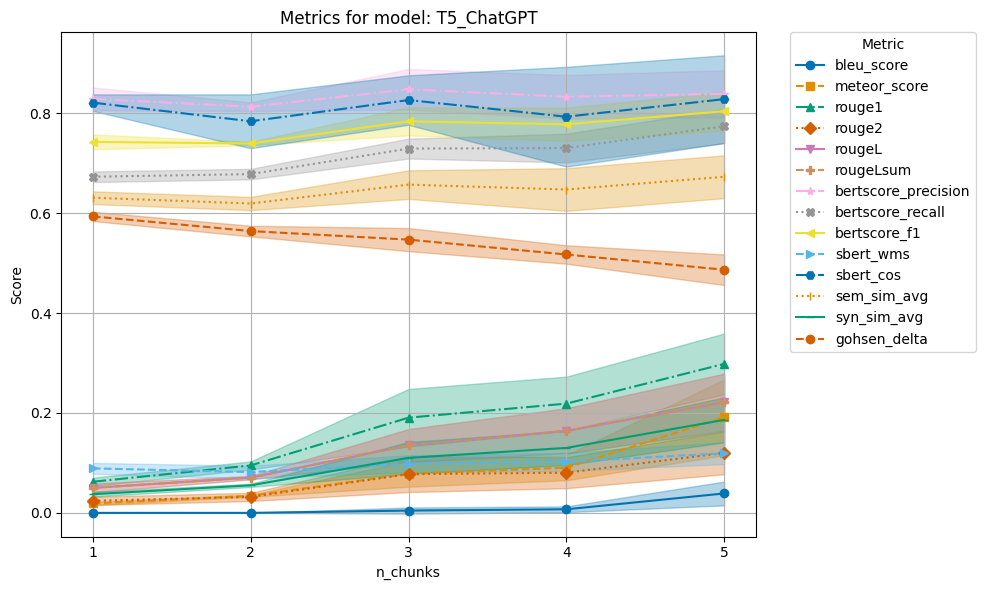

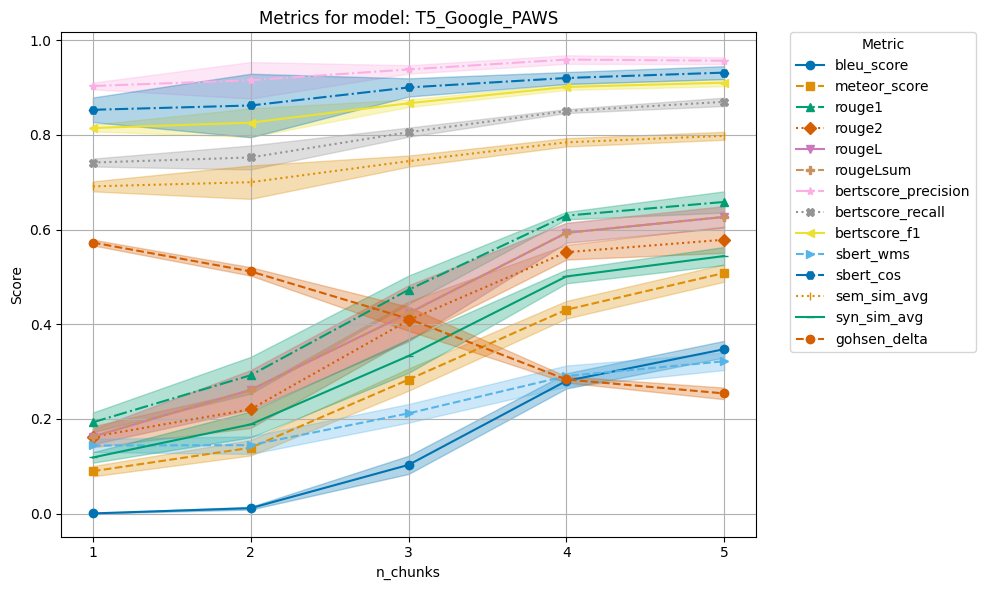

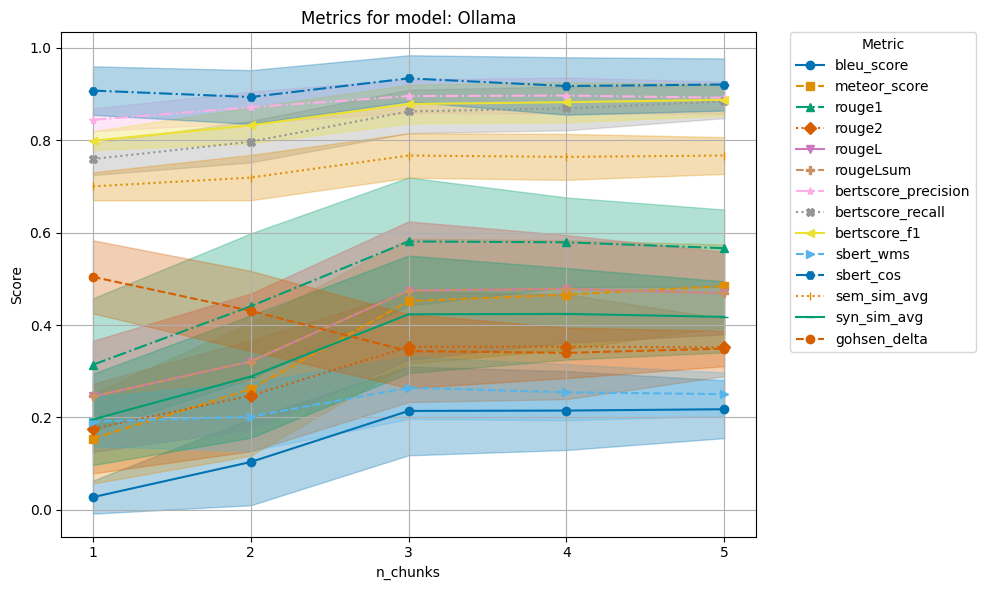

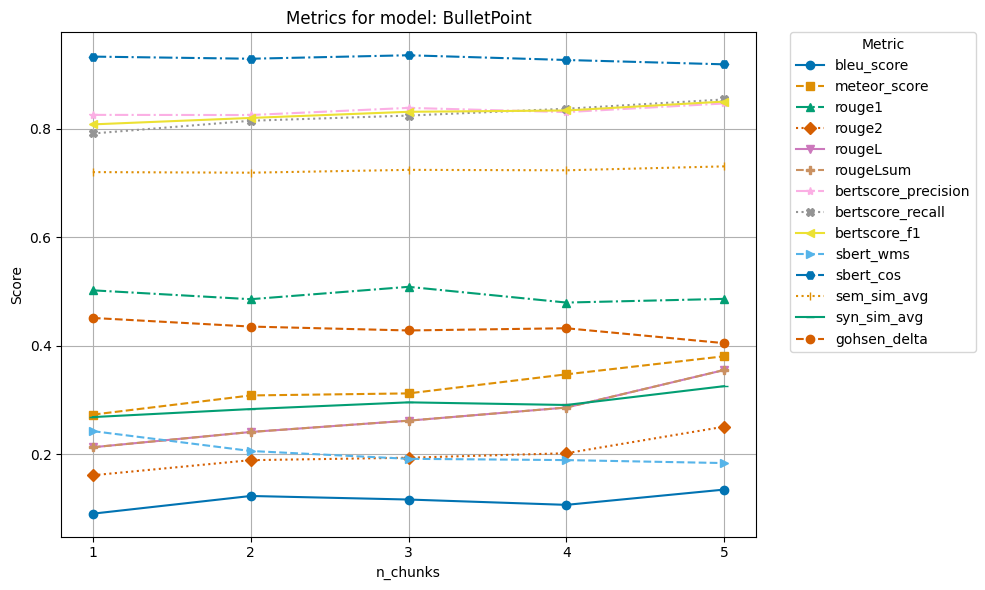

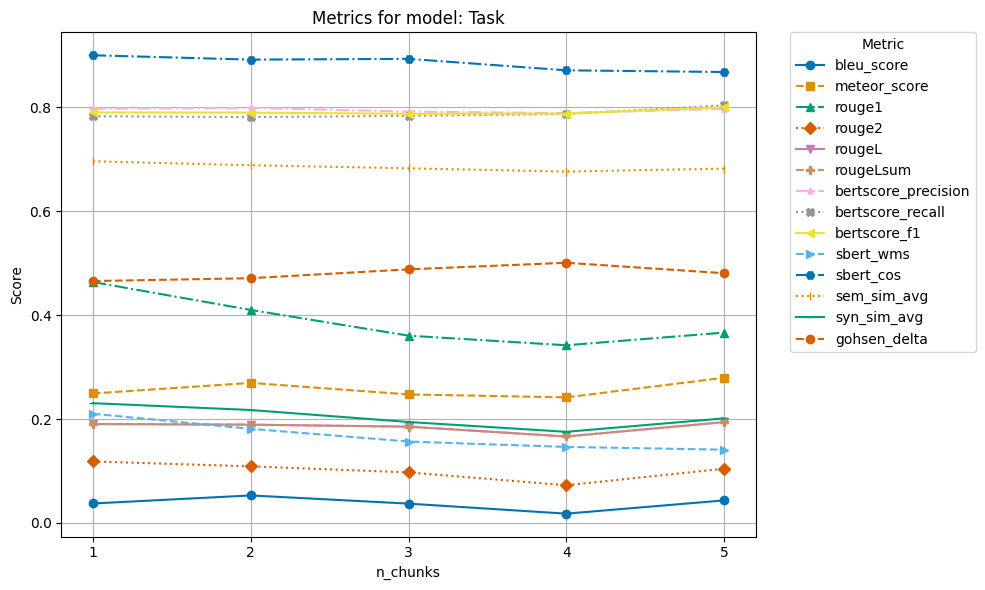

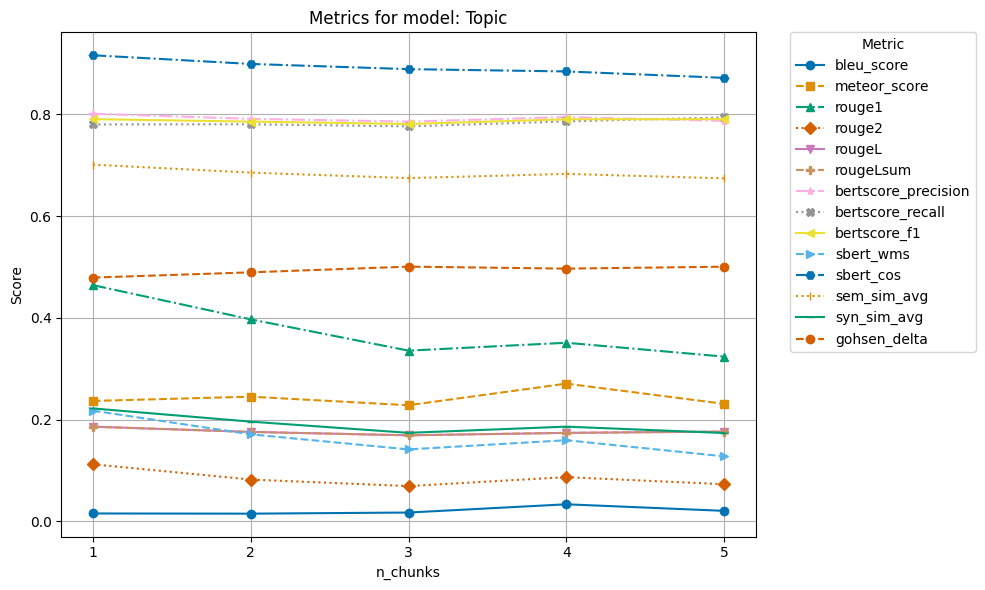

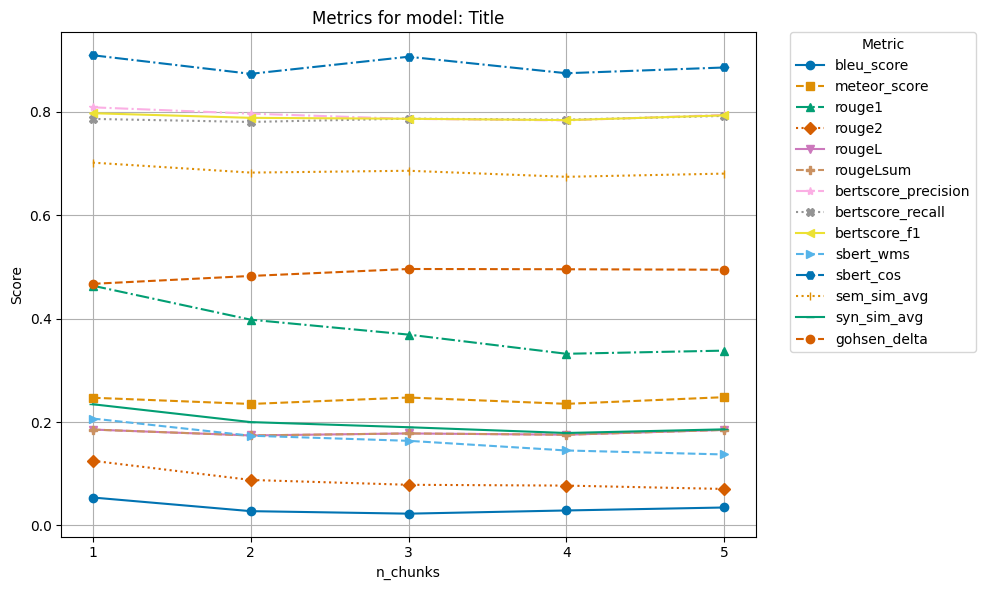

In [16]:
from matplotlib import cm
from matplotlib.ticker import MaxNLocator


def plot_model_metrics(
    n_paragraphs_df, save_dir="model_plots", show=True, save=True, figsize=(10, 6)
):
    """
    Create and save line plots of metric scores per model over n_chunks.

    Parameters:
    - n_paragraphs_df: list of pandas DataFrames with columns ['model', 'prompt', 'n_chunks', <metric columns>]
    - save_dir: directory to save plots (default "model_plots")
    - show: whether to display plots using plt.show()
    - save: whether to save plots to disk
    - figsize: figure size for each plot
    """

    # Combine all DataFrames
    combined_df = pd.concat(n_paragraphs_df, ignore_index=True)

    # Identify models and metrics
    models = combined_df["model"].unique()
    metric_cols = [
        col for col in combined_df.columns if col not in ["model", "prompt", "n_chunks"]
    ]

    # Ensure save directory exists
    if save:
        os.makedirs(save_dir, exist_ok=True)

    # Get color map with enough unique colors
    colors = sns.color_palette("colorblind", len(metric_cols))
    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "^", "D", "v", "P", "*", "X", "<", ">", "H", "|", "_"]

    # Loop over each model
    for model in models:
        df_model = combined_df[combined_df["model"] == model]

        # Group by n_chunks
        grouped = df_model.groupby("n_chunks")
        mean_df = grouped[metric_cols].mean()
        std_df = grouped[metric_cols].std()
        x = mean_df.index

        # Plot
        plt.figure(figsize=figsize)
        for i, metric in enumerate(metric_cols):
            color = colors[i % len(colors)]
            linestyle = line_styles[i % len(line_styles)]
            marker = markers[i % len(markers)]
            plt.plot(
                x,
                mean_df[metric],
                label=metric,
                color=color,
                linestyle=linestyle,
                marker=marker,
            )
            plt.fill_between(
                x,
                mean_df[metric] - std_df[metric],
                mean_df[metric] + std_df[metric],
                color=color,
                alpha=0.3,
            )

        plt.title(f"Metrics for model: {model}")
        plt.xlabel("n_chunks")
        plt.ylabel("Score")
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.legend(
            title="Metric",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            borderaxespad=0.0,
        )
        plt.grid(True)
        plt.tight_layout()

        # Save plot
        if save:
            filename = os.path.join(save_dir, f"{model}_metrics_plot.svg")
            plt.savefig(filename, format="svg", bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close()


plot_model_metrics(slim_n_paragraphs_dfs, save_dir=path2results)